In [ ]:
import pandas as pd

df = pd.read_excel("heart_disease (1).xlsx")

df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [ ]:
import pandas as pd

df = pd.read_excel(
    "heart_disease (1).xlsx",
    sheet_name="Heart_disease"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


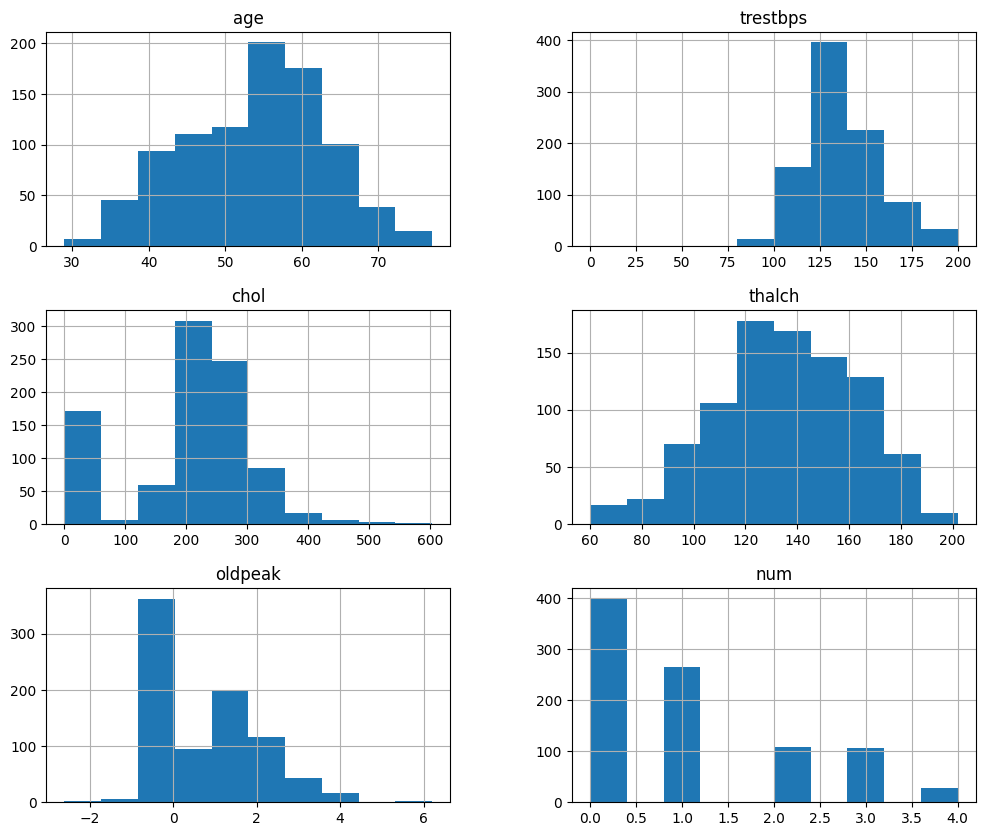

In [ ]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.hist(figsize=(12,10))

plt.show()

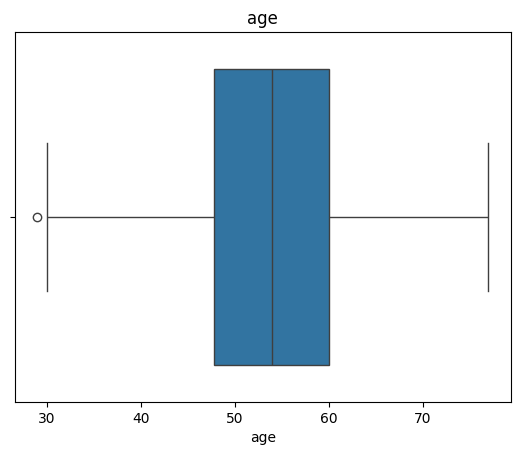

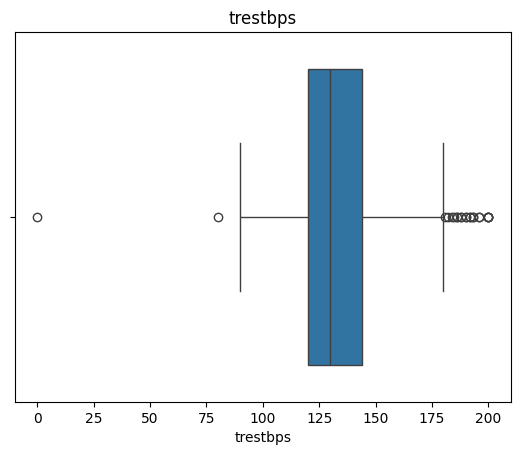

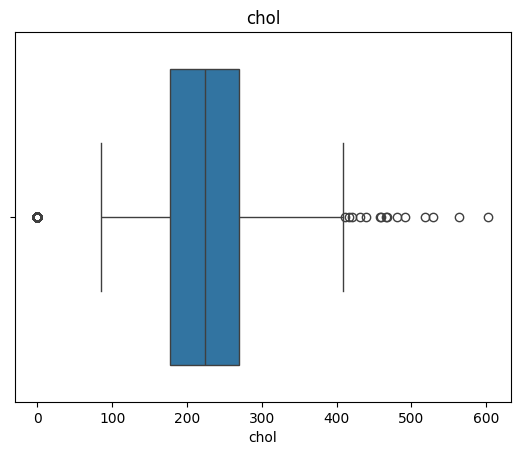

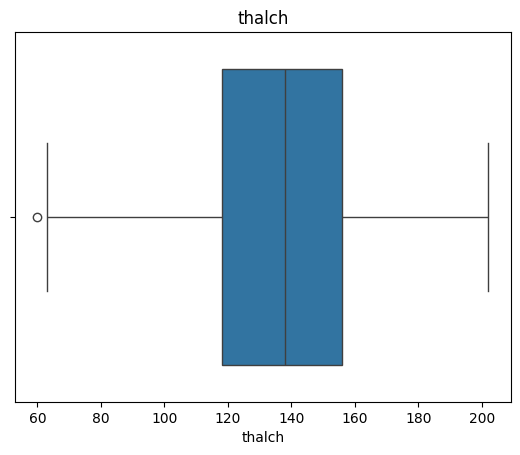

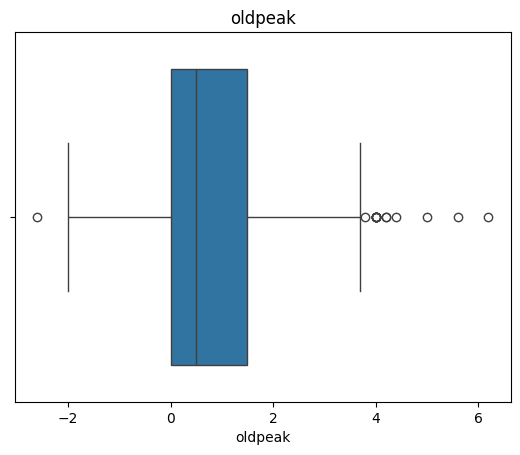

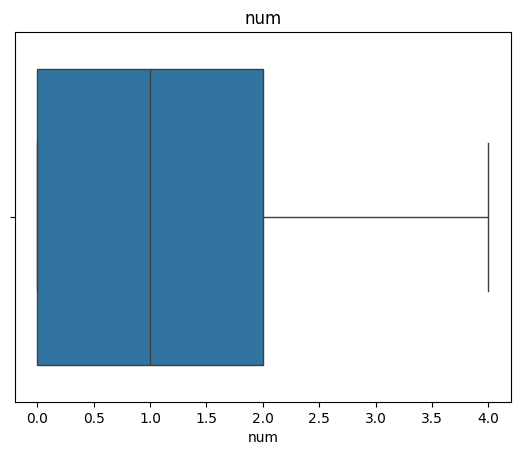

In [ ]:
import seaborn as sns

for col in numeric_df.columns:

    plt.figure()

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

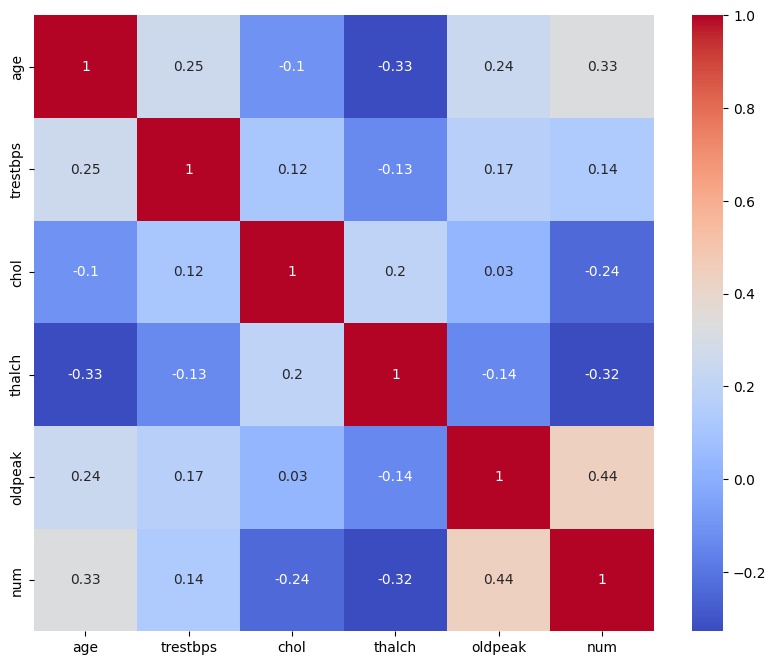

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
df.fillna(
    df.mean(numeric_only=True),
    inplace=True
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    # Convert the column to string type to ensure uniform input for LabelEncoder
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')


In [ ]:
X = df.drop('num', axis=1)

y = df['num']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.521978021978022


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.72      0.73      0.73        89
           1       0.36      0.35      0.36        48
           2       0.40      0.45      0.43        22
           3       0.18      0.18      0.18        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.33      0.34      0.34       182
weighted avg       0.51      0.52      0.52       182



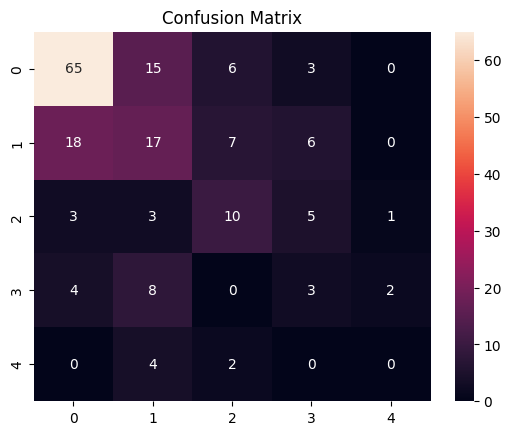

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Get probabilities for all classes
y_prob_all_classes = dt_model.predict_proba(X_test)

print(
    "ROC-AUC Score (OvR, weighted):",
    roc_auc_score(y_test, y_prob_all_classes, multi_class='ovr', average='weighted')
)

ROC-AUC Score (OvR, weighted): 0.65582912964503


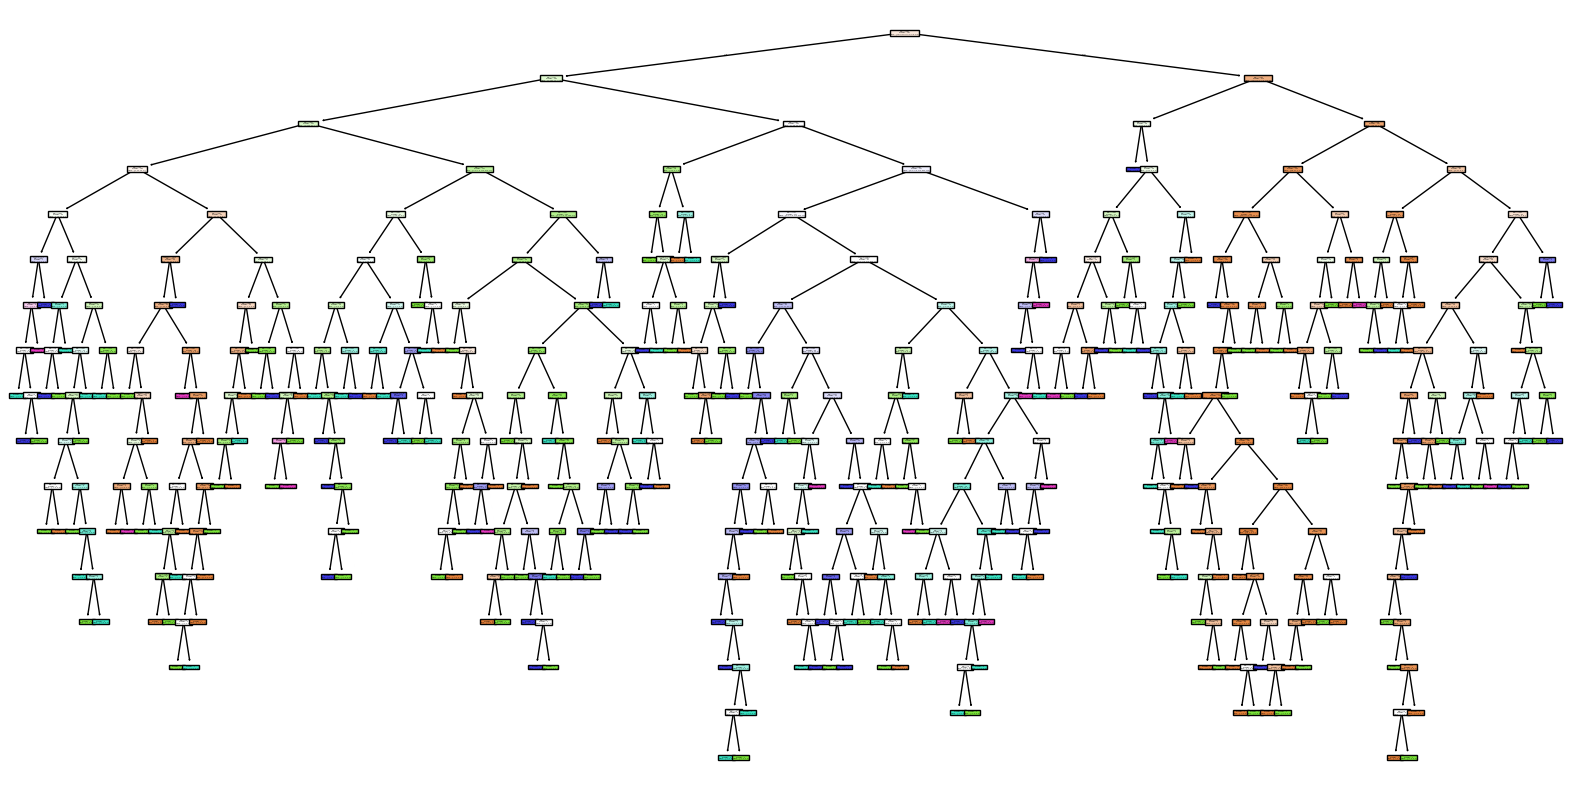

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns
)

plt.show()

In [ ]:
dt_tuned = DecisionTreeClassifier(

    max_depth=5,

    min_samples_split=10,

    criterion='entropy',

    random_state=42
)

dt_tuned.fit(X_train, y_train)

y_pred_tuned = dt_tuned.predict(X_test)

print(
    "Tuned Accuracy:",
    accuracy_score(y_test, y_pred_tuned)
)

Tuned Accuracy: 0.554945054945055


#Interview Questions


#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


Answer: Some of the common hyperparameters in a decision tree are max_depth, min_samples_split, min_samples_leaf, max_features, and the criterion.

Max_depth controls how deep the tree can grow. If the tree is too deep, it may memorize the training data and overfit. If it's too shallow, it may miss important patterns and underfit.

Min_samples_split decides the minimum number of samples required to split a node. Increasing this value makes the tree simpler and helps reduce overfitting.

Min_samples_leaf specifies the minimum number of samples that must be present in a leaf node. Larger values create more stable predictions and make the model less sensitive to noise.

Max_features determines how many features the model considers when looking for the best split. Limiting the number of features can improve generalization and reduce overfitting.

the criterion decides how the quality of a split is measured. For classification, common criteria are Gini Impurity and Entropy, while for regression it's usually Mean Squared Error (MSE).

Overall, these hyperparameters help control the complexity of the decision tree. Proper tuning helps achieve a good balance between underfitting and overfitting, leading to better performance on unseen data.

### 2. What is the difference between the Label encoding and One-hot encoding?

Answer: Label Encoding and One-Hot Encoding are both techniques used to convert categorical data into numerical values so that machine learning models can process them.

In Label Encoding, each category is assigned a unique number. For example, if we have colors like Red, Green, and Blue, they might be encoded as 0, 1, and 2. This method is simple and uses less memory, but it can create an unintended order between categories. A model might incorrectly assume that Blue (2) is greater than Green (1), even though there's no actual relationship.

In One-Hot Encoding, each category gets its own separate column. If we have Red, Green, and Blue, we create three columns. For example, Red becomes [1, 0, 0], Green becomes [0, 1, 0], and Blue becomes [0, 0, 1]. This avoids introducing any order between categories, which makes it a better choice for nominal data.

So, I would typically use Label Encoding for ordinal data, where the categories have a natural order, such as Low, Medium, and High. I would use One-Hot Encoding for nominal data, where the categories don't have any order, such as City, Color, or Country.